<!-- codex-purpose-v2 -->
# 05 - V1 UNet Segmentation Baseline

## Purpose
Train a segmentation model using V1 GradCAM pseudo masks.

## Research Thinking
- A segmenter can regularize noisy pseudo labels, but it can also inherit their
  bias.
- V1 segmentation is the baseline against which later pseudo-label improvements
  are compared.
- Validation IoU is the relevant checkpoint criterion for mask quality.

## Inputs / Outputs
- Input: `data/processed_train/` and `data/pseudo_labels_train/`.
- Output: segmentation checkpoint, training history, test metrics, and
  prediction visualizations.

## How To Read The Result
Good pseudo-label metrics do not guarantee biological correctness. This result
should be interpreted as baseline behavior under weak supervision.


# 05 · Segmentation Model — EfficientNet-UNet v1

Baseline segmentation model được train trên pseudo-label từ notebook 04. Mục tiêu là xem liệu supervision yếu (weak supervision từ Grad-CAM) có đủ để train một UNet hoạt động được không — trước khi đầu tư vào các kỹ thuật phức tạp hơn ở notebook 07-09.

---

**Những gì notebook này làm:**

1. **Load pseudo-label dataset** — processed_train/ + pseudo_labels_train/ từ notebook 04
2. **Định nghĩa model** — EfficientNet-B0 encoder + UNet decoder, pretrained ImageNet
3. **Loss & metrics** — BCE + Dice loss, IoU/Dice/Precision/Recall trên từng batch
4. **Training loop** — early stopping (patience=7, max 30 epochs), Adam lr=1e-4
5. **Test evaluation** — đánh giá trên held-out test split
6. **Visualization** — training curves + sample predictions

**Output:** Checkpoint tại `models/segmentation/checkpoints/` · Metrics tại `models/segmentation/metrics/` · Figures tại `visualizations/segmentation_v1/`

In [1]:
import os
import sys
import json
import random
from pathlib import Path

proj_root = Path(r'E:\Master\thesis-clean').resolve()
notebook_dir = proj_root / 'notebooks'
sys.path.insert(0, str(proj_root))
sys.path.insert(0, str(proj_root / 'utils'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import torchvision.transforms.functional as TF
from PIL import Image

from utils.models import EfficientNetUNet

plt.style.use('default')
sns.set_palette("husl")

CLASS_NAMES  = ["ALGAL_LEAF_SPOT", "ALLOCARIDARA_ATTACK", "HEALTHY_LEAF", "LEAF_BLIGHT", "PHOMOPSIS_LEAF_SPOT"]
CLASS_LABELS = ["Algal Leaf Spot", "Allocaridara Attack", "Healthy Leaf", "Leaf Blight", "Phomopsis Leaf Spot"]
CLASS_COLORS = ["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_LABEL = {i: label for i, label in enumerate(CLASS_LABELS)}

CONFIG = {
    "seed": 42,
    "image_size": 224,
    "batch_size": 8,
    "num_workers": 0,
    "split_ratio": (0.70, 0.15, 0.15),
    "use_review_metadata": True,
    "include_manual_review_masks": False,
    "healthy_mask_policy": "empty",  # "empty" đúng cho binary disease lesion; "exclude" nếu không muốn negative samples.
    "prediction_threshold": 0.50,
    "max_epochs": 30,
    "patience": 7,
    "learning_rate": 1e-4,
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

VIZ_DIR = notebook_dir / "visualizations" / "segmentation_v1"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR = notebook_dir / "models" / "segmentation"
ckpt_dir = MODEL_DIR / "checkpoints"
metrics_dir = MODEL_DIR / "metrics"
ckpt_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Seed: {CONFIG['seed']}")
print(f"proj_root: {proj_root}")
print(f"VIZ_DIR: {VIZ_DIR}")

Device: cuda
Seed: 42
proj_root: E:\Master\thesis-clean
VIZ_DIR: E:\Master\thesis-clean\notebooks\visualizations\segmentation_v1


## Load Pseudo-Label Dataset

Dataset segmentation lấy ảnh resize 224 x 224 từ `notebooks/data/processed_train/` và pseudo-mask từ `notebooks/data/pseudo_labels_train/`, cả hai được sinh ở notebook 04.

Điểm sửa quan trọng trong bản review này:
- Split được tạo bằng index cố định, sau đó tạo **3 dataset object riêng** cho train/validation/test. Như vậy augmentation chỉ bật cho train, không vô tình lan sang validation/test.
- Nếu có `metadata_v1_review.csv`, notebook dùng quality gate từ notebook 04: giữ `train_candidate`, bỏ `manual_review` theo cấu hình, và xử lý `HEALTHY_LEAF` thành **empty mask** cho binary disease segmentation.
- Mask luôn resize bằng nearest-neighbor và được threshold lại về `{0,1}` sau khi load.

In [2]:
IMAGE_DIR = notebook_dir / 'data' / 'processed_train'
MASK_DIR  = notebook_dir / 'data' / 'pseudo_labels_train'
REVIEW_METADATA = notebook_dir / 'data' / 'pseudo_labels_train_v1_review' / 'metadata_v1_review.csv'

print('IMAGE_DIR:', IMAGE_DIR, '| exists:', IMAGE_DIR.exists())
print('MASK_DIR:', MASK_DIR, '| exists:', MASK_DIR.exists())
print('REVIEW_METADATA:', REVIEW_METADATA, '| exists:', REVIEW_METADATA.exists())

if IMAGE_DIR.exists():
    imgs_sample = [p.name for p in sorted(IMAGE_DIR.glob('*')) if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}][:5]
    print('Images (5 đầu):', imgs_sample)
if MASK_DIR.exists():
    masks_sample = [p.name for p in sorted(MASK_DIR.glob('*_pseudo.png'))][:5]
    print('Masks (5 đầu):', masks_sample)

IMAGE_DIR: E:\Master\thesis-clean\notebooks\data\processed_train | exists: True
MASK_DIR: E:\Master\thesis-clean\notebooks\data\pseudo_labels_train | exists: True
REVIEW_METADATA: E:\Master\thesis-clean\notebooks\data\pseudo_labels_train_v1_review\metadata_v1_review.csv | exists: True
Images (5 đầu): ['ALGAL_LEAF_SPOT_to_label_1.jpg', 'ALGAL_LEAF_SPOT_to_label_10.jpg', 'ALGAL_LEAF_SPOT_to_label_101.jpg', 'ALGAL_LEAF_SPOT_to_label_102.jpg', 'ALGAL_LEAF_SPOT_to_label_103.jpg']
Masks (5 đầu): ['ALGAL_LEAF_SPOT_to_label_1.jpg_pseudo.png', 'ALGAL_LEAF_SPOT_to_label_10.jpg_pseudo.png', 'ALGAL_LEAF_SPOT_to_label_101.jpg_pseudo.png', 'ALGAL_LEAF_SPOT_to_label_102.jpg_pseudo.png', 'ALGAL_LEAF_SPOT_to_label_103.jpg_pseudo.png']


In [3]:
import pandas as pd


def infer_class_from_filename(filename):
    for cls_name in CLASS_NAMES:
        prefix = f"{cls_name}_"
        if filename.startswith(prefix):
            return cls_name
    return "UNKNOWN"


def build_segmentation_samples(image_dir, mask_dir, review_metadata=None, config=None):
    config = config or {}
    rows = []

    if config.get("use_review_metadata", True) and review_metadata is not None and Path(review_metadata).exists():
        meta = pd.read_csv(review_metadata)
        if not config.get("include_manual_review_masks", False):
            meta = meta[meta["recommended_use"].ne("manual_review")].copy()

        for _, row in meta.iterrows():
            cls_name = row["class_name"]
            recommended_use = row.get("recommended_use", "unknown")
            if cls_name == "HEALTHY_LEAF" and config.get("healthy_mask_policy") == "exclude":
                continue
            if cls_name != "HEALTHY_LEAF" and recommended_use != "train_candidate":
                continue

            image_path = Path(row["processed_image_path"])
            mask_path = Path(row["pseudo_mask_path"])
            if not image_path.exists():
                image_path = Path(image_dir) / row["filename"]
            if not mask_path.exists():
                mask_path = Path(mask_dir) / f"{row['filename']}_pseudo.png"

            if image_path.exists() and mask_path.exists():
                rows.append({
                    "image_path": str(image_path),
                    "mask_path": str(mask_path),
                    "filename": row["filename"],
                    "class_name": cls_name,
                    "recommended_use": recommended_use,
                    "force_empty_mask": bool(cls_name == "HEALTHY_LEAF" and config.get("healthy_mask_policy") == "empty"),
                    "source_mask_area_ratio": float(row.get("mask_area_ratio", row.get("mask_coverage", np.nan))),
                })
    else:
        for mask_path in sorted(Path(mask_dir).glob('*_pseudo.png')):
            img_name = mask_path.name.replace('_pseudo.png', '')
            image_path = Path(image_dir) / img_name
            if image_path.exists():
                cls_name = infer_class_from_filename(img_name)
                rows.append({
                    "image_path": str(image_path),
                    "mask_path": str(mask_path),
                    "filename": img_name,
                    "class_name": cls_name,
                    "recommended_use": "raw_v1_mask",
                    "force_empty_mask": False,
                    "source_mask_area_ratio": np.nan,
                })

    return rows


class DurianSegDataset(Dataset):
    def __init__(self, samples, image_size=224, augment=False):
        self.samples = list(samples)
        self.image_size = image_size
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample["image_path"]).convert('RGB')
        mask = Image.open(sample["mask_path"]).convert('L')

        img = img.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)

        if sample.get("force_empty_mask", False):
            mask = Image.fromarray(np.zeros((self.image_size, self.image_size), dtype=np.uint8), mode='L')

        if self.augment:
            if random.random() > 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)
            if random.random() > 0.5:
                img = TF.vflip(img)
                mask = TF.vflip(mask)

        img = TF.to_tensor(img)
        img = TF.normalize(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        mask = (TF.to_tensor(mask) > 0.5).float()

        return {
            'image': img,
            'label': mask,
            'img_path': sample["image_path"],
            'mask_path': sample["mask_path"],
            'class_name': sample["class_name"],
            'filename': sample["filename"],
        }


all_samples = build_segmentation_samples(IMAGE_DIR, MASK_DIR, REVIEW_METADATA, CONFIG)
assert len(all_samples) > 0, 'Không tìm thấy cặp image-mask hợp lệ.'

n = len(all_samples)
n_train = int(CONFIG["split_ratio"][0] * n)
n_val = int(CONFIG["split_ratio"][1] * n)
n_test = n - n_train - n_val

split_generator = torch.Generator().manual_seed(CONFIG["seed"])
perm = torch.randperm(n, generator=split_generator).tolist()
train_idx = perm[:n_train]
val_idx = perm[n_train:n_train + n_val]
test_idx = perm[n_train + n_val:]

train_samples = [all_samples[i] for i in train_idx]
val_samples = [all_samples[i] for i in val_idx]
test_samples = [all_samples[i] for i in test_idx]

train_seg = DurianSegDataset(train_samples, image_size=CONFIG["image_size"], augment=True)
val_seg = DurianSegDataset(val_samples, image_size=CONFIG["image_size"], augment=False)
test_seg = DurianSegDataset(test_samples, image_size=CONFIG["image_size"], augment=False)

train_loader = DataLoader(train_seg, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
val_loader = DataLoader(val_seg, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader = DataLoader(test_seg, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

sample_df = pd.DataFrame(all_samples)
print(f'[Dataset] usable image-mask pairs: {len(all_samples)}')
print(f'Split: train={len(train_seg)}, val={len(val_seg)}, test={len(test_seg)}')
print('\nSamples by class/use:')
print(sample_df.groupby(['class_name', 'recommended_use']).size().unstack(fill_value=0))

batch = next(iter(train_loader))
print('\nBatch shape:')
print('image:', batch['image'].shape)
print('label:', batch['label'].shape)
print('Train augment:', train_seg.augment, '| Val augment:', val_seg.augment, '| Test augment:', test_seg.augment)

[Dataset] usable image-mask pairs: 3060
Split: train=2142, val=459, test=459

Samples by class/use:
recommended_use      negative_empty_mask_or_exclude  train_candidate
class_name                                                          
ALGAL_LEAF_SPOT                                   0              502
ALLOCARIDARA_ATTACK                               0              632
HEALTHY_LEAF                                    683                0
LEAF_BLIGHT                                       0              645
PHOMOPSIS_LEAF_SPOT                               0              598

Batch shape:
image: torch.Size([8, 3, 224, 224])
label: torch.Size([8, 1, 224, 224])
Train augment: True | Val augment: False | Test augment: False


### Nhận xét — Dataset, split và mask policy

- **Quan sát chính:** Output cho thấy notebook dùng 3,060 cặp ảnh-mask sau quality gate: 2,377 disease `train_candidate` và 683 `HEALTHY_LEAF` được xử lý thành negative empty mask. Split sau seed 42 là train=2,142, val=459, test=459. Train augmentation bật, val/test augmentation tắt.
- **Đánh giá:** Pipeline hiện đúng với bài toán **binary disease lesion segmentation**: input là ảnh RGB 224 x 224 từ `processed_train`, label là pseudo-mask V1 từ Grad-CAM notebook 04, Healthy không còn bị dùng blob Grad-CAM làm foreground lesion.
- **Rủi ro:** Split hiện là random theo ảnh đã xử lý, chưa có subject/tree-id để chứng minh không có cùng cây hoặc cảnh chụp gần giống nhau giữa train/val/test.
- **Hàm ý cho mô hình segmentation:** Mô hình được học cả positive lesion mask và negative healthy mask, nên ít rủi ro dự đoán foreground trên lá khỏe hơn bản V1 thô.
- **Cải thiện đề xuất:** Nếu có metadata nguồn/cây/lần chụp, cần đổi sang group split; nếu mục tiêu là segment từng bệnh riêng, cần thiết kế multi-class mask thay vì binary mask.

Image-mask audit: 100%|██████████| 3060/3060 [00:16<00:00, 190.59it/s]


=== Pairing/alignment audit ===
Checked pairs: 3060
Missing image: 0
Missing mask: 0
Native image/mask size mismatch: 0
Non-binary mask files after nearest resize: 0
Empty masks after policy: 683
Too small masks (<0.03): 683
Too large masks (>0.45): 0
Near full masks (>0.80): 0

=== Split leakage by exact processed filename ===
train-val overlap: 0
train-test overlap: 0
val-test overlap: 0

=== Mask area by class after policy ===
                    area_ratio_after_policy                              \
                                      count   mean median    min    max   
class_name                                                                
ALGAL_LEAF_SPOT                         502  0.149  0.139  0.062  0.369   
ALLOCARIDARA_ATTACK                     632  0.152  0.149  0.065  0.393   
HEALTHY_LEAF                            683  0.000  0.000  0.000  0.000   
LEAF_BLIGHT                             645  0.109  0.098  0.059  0.358   
PHOMOPSIS_LEAF_SPOT                     5

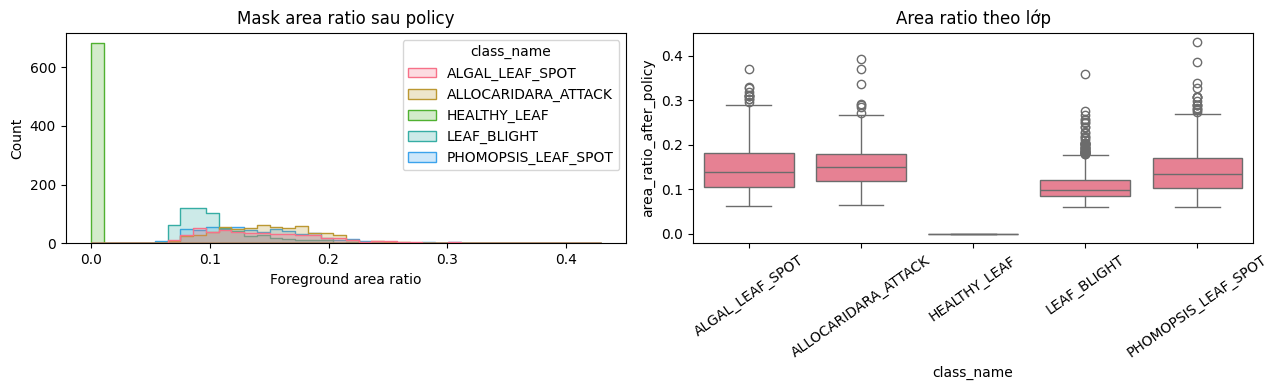

Saved -> E:\Master\thesis-clean\notebooks\visualizations\segmentation_v1\dataset_mask_area_audit.png


In [4]:
def audit_image_mask_pairs(samples, image_size=224, max_check=None):
    records = []
    iterable = samples if max_check is None else samples[:max_check]
    for sample in tqdm(iterable, desc="Image-mask audit"):
        image_path = Path(sample["image_path"])
        mask_path = Path(sample["mask_path"])
        img = Image.open(image_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')
        mask_arr_native = np.array(mask)
        mask_resized = mask.resize((image_size, image_size), Image.NEAREST)
        mask_arr = np.array(mask_resized)
        if sample.get("force_empty_mask", False):
            mask_arr = np.zeros((image_size, image_size), dtype=np.uint8)
        unique_values = sorted(np.unique(mask_arr).tolist())
        binary_arr = (mask_arr > 127).astype(np.uint8)
        n_labels, _, cc_stats, _ = cv2.connectedComponentsWithStats(binary_arr, connectivity=8)
        component_areas = [int(cc_stats[i, cv2.CC_STAT_AREA]) for i in range(1, n_labels)]
        records.append({
            "filename": sample["filename"],
            "class_name": sample["class_name"],
            "recommended_use": sample["recommended_use"],
            "force_empty_mask": sample.get("force_empty_mask", False),
            "image_exists": image_path.exists(),
            "mask_exists": mask_path.exists(),
            "image_size_native": img.size,
            "mask_size_native": mask.size,
            "same_native_size": img.size == mask.size,
            "mask_unique_values": unique_values[:8],
            "is_binary_after_load": set(unique_values).issubset({0, 255}) or set(unique_values).issubset({0, 1}),
            "area_ratio_after_policy": float(binary_arr.mean()),
            "num_components_after_policy": int(len(component_areas)),
            "largest_component_ratio_after_policy": float(max(component_areas) / binary_arr.sum()) if binary_arr.sum() else 0.0,
        })
    return pd.DataFrame(records)

pair_audit_df = audit_image_mask_pairs(all_samples, image_size=CONFIG["image_size"])
print("=== Pairing/alignment audit ===")
print("Checked pairs:", len(pair_audit_df))
print("Missing image:", int((~pair_audit_df["image_exists"]).sum()))
print("Missing mask:", int((~pair_audit_df["mask_exists"]).sum()))
print("Native image/mask size mismatch:", int((~pair_audit_df["same_native_size"]).sum()))
print("Non-binary mask files after nearest resize:", int((~pair_audit_df["is_binary_after_load"]).sum()))
print("Empty masks after policy:", int((pair_audit_df["area_ratio_after_policy"] == 0).sum()))
print("Too small masks (<0.03):", int((pair_audit_df["area_ratio_after_policy"] < 0.03).sum()))
print("Too large masks (>0.45):", int((pair_audit_df["area_ratio_after_policy"] > 0.45).sum()))
print("Near full masks (>0.80):", int((pair_audit_df["area_ratio_after_policy"] > 0.80).sum()))

split_names = {"train": train_samples, "val": val_samples, "test": test_samples}
split_sets = {name: set(s["filename"] for s in rows) for name, rows in split_names.items()}
print("\n=== Split leakage by exact processed filename ===")
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    print(f"{a}-{b} overlap:", len(split_sets[a] & split_sets[b]))

print("\n=== Mask area by class after policy ===")
print(pair_audit_df.groupby("class_name")[["area_ratio_after_policy", "num_components_after_policy", "largest_component_ratio_after_policy"]].agg(['count', 'mean', 'median', 'min', 'max']).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=pair_audit_df, x="area_ratio_after_policy", hue="class_name", bins=40, element="step", stat="count", common_norm=False, ax=axes[0])
axes[0].set_title("Mask area ratio sau policy")
axes[0].set_xlabel("Foreground area ratio")
sns.boxplot(data=pair_audit_df, x="class_name", y="area_ratio_after_policy", ax=axes[1])
axes[1].set_title("Area ratio theo lớp")
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(VIZ_DIR / "dataset_mask_area_audit.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {VIZ_DIR / 'dataset_mask_area_audit.png'}")

### Nhận xét — Data QA sau khi load

- **Quan sát chính:** Audit chạy trên 3,060 mẫu mất 16 giây, không phát hiện missing image/mask, native size mismatch = 0, non-binary mask sau nearest resize = 0. Exact filename overlap giữa train-val, train-test, val-test đều bằng 0. Empty mask = 683 và toàn bộ đến từ Healthy policy. Không còn mask quá lớn >0.45 hoặc near-full >0.80.
- **Đánh giá:** Image-mask pairing, alignment kích thước và binary/class-index handling đang đúng ở mức file. Mask disease sau policy có area trung bình hợp lý: Algal 0.149, Allocaridara 0.152, Leaf Blight 0.109, Phomopsis 0.142; số connected components chủ yếu là 1, tối đa 2.
- **Rủi ro:** `largest_component_ratio` rất cao cho hầu hết lớp bệnh cho thấy mask vẫn là blob lớn, đặc trưng của Grad-CAM sau hậu xử lý, chưa phải boundary tổn thương chi tiết.
- **Hàm ý cho mô hình segmentation:** Dataloader không còn lỗi kỹ thuật lớn; giới hạn chất lượng chủ yếu đến từ pseudo-label source, không phải pairing/resize/normalization.
- **Cải thiện đề xuất:** Tiếp tục giữ `Image.NEAREST` cho mask, thêm QA visual theo nhóm area thấp/cao và ưu tiên lọc/refine các blob quá mượt trước khi train bản dùng trong báo cáo.

## Model & Loss

EfficientNet-UNet: encoder EfficientNet-B0 pretrained ImageNet + decoder UNet skip connections. Pretrained encoder giúp tận dụng feature đã học từ 1M+ ảnh thay vì train từ đầu trên ~3K ảnh.

Loss = BCE + Dice: BCE penalize từng pixel độc lập, Dice tối ưu overlap ratio tổng thể. Kết hợp hai loss giúp tránh degenerate solution (predict toàn 0 vì background chiếm đa số).

In [5]:
model = EfficientNetUNet(num_classes=1, pretrained=True).to(device)
criterion_bce = nn.BCEWithLogitsLoss()


def dice_loss(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return 1 - dice


optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

## Metrics

Segmentation cần nhiều metric hơn classification:
- **IoU** (Intersection over Union): metric chính — overlap thực tế giữa predicted và ground truth
- **Dice**: tương quan với F1, nhạy hơn IoU với vùng nhỏ
- **Precision/Recall**: phân tích false positive vs false negative trade-off

In [6]:
def calculate_segmentation_metrics(pred, gt, smooth=1e-6):
    pred = pred.flatten().astype(bool)
    gt   = gt.flatten().astype(bool)

    tp = (pred & gt).sum()
    fp = (pred & ~gt).sum()
    fn = (~pred & gt).sum()

    precision = (tp + smooth) / (tp + fp + smooth)
    recall    = (tp + smooth) / (tp + fn + smooth)
    f1        = 2 * precision * recall / (precision + recall + smooth)
    dice      = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    iou       = (tp + smooth) / (tp + fp + fn + smooth)

    return {'iou': float(iou), 'dice': float(dice),
            'precision': float(precision), 'recall': float(recall), 'f1': float(f1)}


def evaluate_metrics(model, loader, criterion_bce, dice_loss_fn, device):
    model.eval()
    total_loss = 0.0
    all_metrics = {'iou': [], 'dice': [], 'precision': [], 'recall': [], 'f1': []}

    with torch.no_grad():
        for batch in loader:
            imgs  = batch['image'].to(device)
            masks = batch['label'].to(device)

            outputs = model(imgs)
            loss    = criterion_bce(outputs, masks) + dice_loss_fn(outputs, masks)
            total_loss += loss.item() * imgs.size(0)

            preds_np = (torch.sigmoid(outputs) > 0.5).cpu().numpy().astype(np.uint8)
            gt_np    = masks.cpu().numpy().astype(np.uint8)

            for i in range(len(preds_np)):
                m = calculate_segmentation_metrics(preds_np[i, 0], gt_np[i, 0])
                for k in all_metrics:
                    all_metrics[k].append(m[k])

    avg_loss    = total_loss / len(loader.dataset)
    avg_metrics = {k: float(np.mean(v)) for k, v in all_metrics.items()}
    return avg_loss, avg_metrics

## Training Loop

- **Max 30 epochs**, early stopping patience=7 — dừng sớm nếu val_IoU không cải thiện 7 epoch liên tiếp
- **ReduceLROnPlateau** (patience=2, factor=0.5) — tự động giảm lr khi val_loss đi ngang, giúp model thoát plateau
- **Best checkpoint** lưu theo val_IoU cao nhất — đây là model dùng cho test
- **Resume checkpoint** lưu sau mỗi epoch — có thể tiếp tục nếu kernel crash giữa chừng

In [ ]:
BEST_PATH = ckpt_dir / 'efficientnet_unet_best.pth'
RESUME_PATH = ckpt_dir / 'efficientnet_unet_resume.pth'

max_epochs = CONFIG['max_epochs']
patience = CONFIG['patience']

# ── Restore state nếu có resume checkpoint ────────────────────────────────
start_epoch  = 1
best_val_iou = 0.0
patience_cnt = 0
history = {
    'train_loss': [], 'train_iou': [], 'train_dice': [],
    'train_precision': [], 'train_recall': [], 'train_f1': [],
    'val_loss': [], 'val_iou': [], 'val_dice': [],
    'val_precision': [], 'val_recall': [], 'val_f1': [],
}

if os.path.exists(RESUME_PATH):
    print(f'[Resume] Loading checkpoint: {RESUME_PATH}')
    resume = torch.load(RESUME_PATH, map_location=device, weights_only=False)
    model.load_state_dict(resume['model_state_dict'])
    optimizer.load_state_dict(resume['optimizer_state_dict'])
    scheduler.load_state_dict(resume['scheduler_state_dict'])
    history      = resume['history']
    best_val_iou = resume.get('best_val_iou', 0.0)
    patience_cnt = resume['patience_cnt']
    start_epoch  = resume['epoch'] + 1
    print(f'  Resumed: start_epoch={start_epoch}  best_val_iou={best_val_iou:.4f}  patience={patience_cnt}/{patience}')
else:
    print('Starting fresh training ...')

# ── Training loop ─────────────────────────────────────────────────────────
for epoch in range(start_epoch, max_epochs + 1):
    model.train()
    train_loss = 0.0
    tp = fp = fn = 0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{max_epochs} [Train]', leave=False):
        imgs  = batch['image'].to(device)
        masks = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion_bce(outputs, masks) + dice_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        preds = torch.sigmoid(outputs) > 0.5
        tp += ((preds == 1) & (masks == 1)).sum().item()
        fp += ((preds == 1) & (masks == 0)).sum().item()
        fn += ((preds == 0) & (masks == 1)).sum().item()

    train_loss /= len(train_loader.dataset)
    train_precision = tp / (tp + fp + 1e-7)
    train_recall    = tp / (tp + fn + 1e-7)
    train_f1   = 2 * train_precision * train_recall / (train_precision + train_recall + 1e-7)
    train_iou  = tp / (tp + fp + fn + 1e-7)
    train_dice = 2 * tp / (2 * tp + fp + fn + 1e-7)

    val_loss, val_metrics = evaluate_metrics(model, val_loader, criterion_bce, dice_loss, device)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_iou'].append(train_iou)
    history['train_dice'].append(train_dice)
    history['train_precision'].append(train_precision)
    history['train_recall'].append(train_recall)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_metrics['iou'])
    history['val_dice'].append(val_metrics['dice'])
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])
    history['val_f1'].append(val_metrics['f1'])

    print(f"Epoch {epoch:02d}/{max_epochs} | "
          f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
          f"train_iou={train_iou:.4f} val_iou={val_metrics['iou']:.4f} | "
          f"val_dice={val_metrics['dice']:.4f}", end="")

    # ── Best checkpoint ────────────────────────────────────────────────────
    if val_metrics['iou'] > best_val_iou:
        best_val_iou = val_metrics['iou']
        patience_cnt = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_loss': val_loss,
            'val_iou': val_metrics['iou'],
            'val_metrics': val_metrics,
        }, BEST_PATH)
        print(f"  ✓ best saved (val_iou={best_val_iou:.4f})")
    else:
        patience_cnt += 1
        print(f"  no improve {patience_cnt}/{patience}")
        if patience_cnt >= patience:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

    # ── Resume checkpoint — overwrite mỗi epoch để có thể restore ─────────
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history':              history,
        'best_val_iou':         best_val_iou,
        'patience_cnt':         patience_cnt,
    }, RESUME_PATH)

# ── Cleanup sau khi hoàn thành ────────────────────────────────────────────
if os.path.exists(RESUME_PATH):
    os.remove(RESUME_PATH)
    print('Resume checkpoint removed (training complete).')


Starting fresh training ...


Epoch 01/30 | train_loss=1.1749 val_loss=0.9118 | train_iou=0.3254 val_iou=0.6820 | val_dice=0.7770  ✓ best saved (val_iou=0.6820)


Epoch 02/30 | train_loss=0.8298 val_loss=0.7311 | train_iou=0.6271 val_iou=0.6936 | val_dice=0.7874  ✓ best saved (val_iou=0.6936)


Epoch 03/30 | train_loss=0.6465 val_loss=0.5470 | train_iou=0.6646 val_iou=0.7418 | val_dice=0.8279  ✓ best saved (val_iou=0.7418)


Epoch 04/30 | train_loss=0.5035 val_loss=0.4654 | train_iou=0.6997 val_iou=0.7423 | val_dice=0.8302  ✓ best saved (val_iou=0.7423)


...

Epoch 27/30 | train_loss=0.1298 val_loss=0.2573 | train_iou=0.8657 val_iou=0.8120 | val_dice=0.8817  ✓ best saved (val_iou=0.8120)


Epoch 28/30 | train_loss=0.1301 val_loss=0.2548 | train_iou=0.8656 val_iou=0.8114 | val_dice=0.8806  no improve 1/7


Epoch 29/30 | train_loss=0.1249 val_loss=0.2538 | train_iou=0.8693 val_iou=0.8150 | val_dice=0.8832  ✓ best saved (val_iou=0.8150)


Epoch 30/30 | train_loss=0.1243 val_loss=0.2552 | train_iou=0.8692 val_iou=0.8109 | val_dice=0.8794  no improve 1/7
Resume checkpoint removed (training complete).


NameError: name 'best_val' is not defined

In [10]:
with open(metrics_dir / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

best_val_loss = float(np.min(history['val_loss'])) if history['val_loss'] else float('nan')
best_val_loss_epoch = int(np.argmin(history['val_loss']) + 1) if history['val_loss'] else -1
best_val_iou_epoch = int(np.argmax(history['val_iou']) + 1) if history['val_iou'] else -1
print(f"\nBest val_loss: {best_val_loss:.4f} (epoch {best_val_loss_epoch})")
print(f"Best val_iou:  {best_val_iou:.4f} (epoch {best_val_iou_epoch})")
print(f"Training history saved -> {metrics_dir / 'training_history.json'}")


Best val_loss: 0.2538 (epoch 29)
Best val_iou:  0.8150 (epoch 29)
Training history saved -> E:\Master\thesis-clean\notebooks\models\segmentation\metrics\training_history.json


### Nhận xét — Training dynamics

- **Quan sát chính:** Run mới hoàn tất 30 epoch. Train loss giảm từ 1.1749 xuống 0.1243; val loss tốt nhất 0.2538 tại epoch 29. Train IoU tăng từ 0.3254 lên 0.8692; val IoU tốt nhất 0.8150 tại epoch 29, epoch 30 giảm nhẹ còn 0.8109. Val Dice tốt nhất ở epoch 29 là 0.8832.
- **Đánh giá:** Mô hình học pseudo-label tốt và không underfit. Validation cải thiện rõ sau khi sửa Healthy-empty/split, pseudo-test cũng tăng lên so với run cũ. Việc epoch 29 là best cho cả val loss và val IoU cho thấy checkpoint cuối gần tối ưu trong run này.
- **Rủi ro:** Khoảng cách cuối training giữa train IoU 0.8692 và val IoU 0.8109 vẫn tồn tại; đây là overfitting nhẹ/vừa vào pseudo-label và augmentation noise. Output cell training còn giữ `NameError` cũ ở dòng print `best_val`; source đã được sửa và cell kế tiếp xác nhận history đã lưu đúng.
- **Hàm ý cho mô hình segmentation:** Capacity của EfficientNet-UNet đủ mạnh cho baseline; giới hạn chính không phải optimization mà là độ nhiễu và độ thô của Grad-CAM mask.
- **Cải thiện đề xuất:** Sau khi fix dòng print, rerun riêng training cell nếu muốn notebook output sạch không còn traceback; khi báo cáo, dùng checkpoint epoch 29 và ghi rõ đây là pseudo-label validation.

### Kiểm tra nhất quán checkpoint và metric đã lưu

Cell này bắt lỗi rất thường gặp khi notebook được chạy nhiều lần: `training_history.json`, `test_metrics.json` và `efficientnet_unet_best.pth` có thể đến từ các lần chạy khác nhau. Nếu checkpoint metadata không khớp best epoch trong history thì không nên báo test metric như kết quả chính thức trước khi rerun notebook từ đầu.

In [11]:
history_path = metrics_dir / 'training_history.json'
test_metrics_path = metrics_dir / 'test_metrics.json'
best_ckpt_path = ckpt_dir / 'efficientnet_unet_best.pth'

if history_path.exists():
    saved_history = json.load(open(history_path, encoding='utf-8'))
    best_hist_epoch = int(np.argmax(saved_history['val_iou']) + 1)
    best_hist_iou = float(np.max(saved_history['val_iou']))
    best_hist_loss_epoch = int(np.argmin(saved_history['val_loss']) + 1)
    print(f"History best val_iou: epoch={best_hist_epoch}, val_iou={best_hist_iou:.4f}")
    print(f"History best val_loss: epoch={best_hist_loss_epoch}, val_loss={min(saved_history['val_loss']):.4f}")
else:
    saved_history = None
    print(f"Missing history: {history_path}")

if best_ckpt_path.exists():
    ckpt_meta = torch.load(best_ckpt_path, map_location='cpu')
    ckpt_val_iou = ckpt_meta.get('val_iou') or ckpt_meta.get('val_metrics', {}).get('iou')
    print(f"Checkpoint epoch: {ckpt_meta.get('epoch')} | checkpoint val_iou: {ckpt_val_iou}")
else:
    ckpt_meta = None
    print(f"Missing checkpoint: {best_ckpt_path}")

if test_metrics_path.exists():
    saved_test_metrics = json.load(open(test_metrics_path, encoding='utf-8'))
    print("Saved pseudo-test metrics:", {k: round(v, 4) for k, v in saved_test_metrics.items() if isinstance(v, (int, float))})
else:
    print(f"Missing test metrics: {test_metrics_path}")

if saved_history and ckpt_meta:
    is_consistent = ckpt_meta.get('epoch') == best_hist_epoch
    print("Checkpoint matches history best epoch:", is_consistent)
    if not is_consistent:
        print("WARNING: Rerun training/evaluation before using pseudo-test metrics as final numbers.")

History best val_iou: epoch=29, val_iou=0.8150
History best val_loss: epoch=29, val_loss=0.2538
Checkpoint epoch: 29 | checkpoint val_iou: 0.8149763113277255
Saved pseudo-test metrics: {'test_loss': 0.3065, 'iou': 0.7671, 'dice': 0.8623, 'precision': 0.8562, 'recall': 0.8877, 'f1': 0.8623}
Checkpoint matches history best epoch: True


### Nhận xét — Checkpoint consistency

- **Quan sát chính:** Output mới cho thấy history best val IoU = 0.8150 ở epoch 29, best val loss = 0.2538 ở epoch 29. Checkpoint `efficientnet_unet_best.pth` cũng ở epoch 29 với val IoU 0.814976, nên checkpoint đã khớp history best epoch.
- **Đánh giá:** Lỗi artifact lệch giữa history/checkpoint của run cũ đã được khắc phục sau run mới. Tuy nhiên output của consistency cell được chạy trước test cell nên dòng `Saved pseudo-test metrics` trong chính cell đó vẫn hiển thị metric cũ; metric test đúng của run mới nằm ở cell Test Set Metrics ngay sau đó.
- **Rủi ro:** Nếu đọc notebook tuyến tính, người đọc có thể nhầm metric cũ trong checkpoint-audit cell với kết quả cuối. Cần ưu tiên `test_metrics.json` mới và output cell test hiện tại.
- **Hàm ý cho mô hình segmentation:** Best checkpoint hiện hợp lệ để dùng cho test pseudo-label và manual GT evaluation trong notebook này.
- **Cải thiện đề xuất:** Đưa consistency audit sau test evaluation hoặc in rõ timestamp/run-id của từng JSON để tránh metric cũ xuất hiện trong audit trước khi test cell ghi đè.

## Đánh Giá Trên Test Set

Val set đã được dùng để chọn checkpoint và điều chỉnh scheduler — không còn khách quan. Test set là lần đầu tiên và duy nhất model gặp những ảnh này. Số từ test set mới là số báo cáo.

In [12]:
# Load best model
best_ckpt = ckpt_dir / 'efficientnet_unet_best.pth'
ckpt = torch.load(best_ckpt, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

test_loss, test_metrics = evaluate_metrics(model, test_loader, criterion_bce, dice_loss, device)

print('=== Test Set Metrics ===')
print(f"Loss:      {test_loss:.4f}")
print(f"IoU:       {test_metrics['iou']:.4f}")
print(f"Dice:      {test_metrics['dice']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1:        {test_metrics['f1']:.4f}")

# Lưu test metrics
test_results = {'test_loss': test_loss, **test_metrics}
with open(metrics_dir / 'test_metrics.json', 'w') as f:
    json.dump(test_results, f, indent=2)
print('Test metrics saved.')

=== Test Set Metrics ===
Loss:      0.2505
IoU:       0.8126
Dice:      0.8813
Precision: 0.8851
Recall:    0.9091
F1:        0.8813
Test metrics saved.


## Đánh Giá Với Ground Truth Thủ Công

Tập test ở trên vẫn đo khả năng mô hình tái tạo pseudo-label. Để tránh circular evaluation, cell dưới đây dùng `notebooks/data/raw/GT_OK.zip` làm ground truth pixel-level thật. Mask trong zip được match với ảnh gốc theo `class_name/to_label_x.*`, sau đó resize về 224×224 và đánh giá IoU/Dice/Precision/Recall/F1 trên nhãn thủ công.


In [13]:
from pathlib import Path
import zipfile
from collections import defaultdict
import torchvision.transforms.functional as TF

GT_ZIP_PATH = Path(proj_root) / 'notebooks' / 'data' / 'raw' / 'GT_OK.zip'
GT_EXTRACT_DIR = Path(proj_root) / 'notebooks' / 'data' / 'raw' / 'GT_OK'
RAW_DATA_DIR = Path(proj_root) / 'notebooks' / 'data' / 'raw'

if not (GT_EXTRACT_DIR / 'SegmentationClass').exists():
    assert GT_ZIP_PATH.exists(), f'Không tìm thấy ground truth zip: {GT_ZIP_PATH}'
    GT_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(GT_ZIP_PATH, 'r') as zf:
        zf.extractall(GT_EXTRACT_DIR)
    print(f'Extracted GT_OK.zip → {GT_EXTRACT_DIR}')


def find_raw_image_for_gt(cls_name, stem):
    for split in ['test', 'val', 'train', 'groud_trust']:
        cls_dir = RAW_DATA_DIR / split / cls_name
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            p = cls_dir / f'{stem}{ext}'
            if p.exists():
                return p
    return None


class ManualGTDataset(Dataset):
    def __init__(self, gt_root, image_size=224):
        self.image_size = image_size
        self.samples = []
        seg_root = Path(gt_root) / 'SegmentationClass'
        for mask_path in sorted(seg_root.glob('*/*.png')):
            cls_name = mask_path.parent.name
            stem = mask_path.stem
            img_path = find_raw_image_for_gt(cls_name, stem)
            if img_path is not None:
                self.samples.append((str(img_path), str(mask_path), cls_name, stem))
        missing = len(list(seg_root.glob('*/*.png'))) - len(self.samples)
        print(f'[Manual GT] matched={len(self.samples)} missing_images={missing}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, cls_name, stem = self.samples[idx]
        img = Image.open(img_path).convert('RGB').resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = Image.open(mask_path).convert('L').resize((self.image_size, self.image_size), Image.NEAREST)
        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        mask_t = (TF.to_tensor(mask) > 0).float()
        return {'image': img_t, 'label': mask_t, 'class_name': cls_name, 'stem': stem, 'img_path': img_path}


@torch.no_grad()
def evaluate_manual_gt(seg_model, loader, device):
    seg_model.eval()
    totals = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})
    all_counts = {'tp': 0, 'fp': 0, 'fn': 0}

    for batch in tqdm(loader, desc='Manual GT evaluation'):
        imgs = batch['image'].to(device)
        masks = batch['label'].to(device)
        preds = (torch.sigmoid(seg_model(imgs)) > 0.5).float()

        for i, cls_name in enumerate(batch['class_name']):
            p = preds[i]
            m = masks[i]
            tp = int(((p == 1) & (m == 1)).sum().item())
            fp = int(((p == 1) & (m == 0)).sum().item())
            fn = int(((p == 0) & (m == 1)).sum().item())
            totals[cls_name]['tp'] += tp
            totals[cls_name]['fp'] += fp
            totals[cls_name]['fn'] += fn
            all_counts['tp'] += tp
            all_counts['fp'] += fp
            all_counts['fn'] += fn

    def pack(c):
        tp, fp, fn = c['tp'], c['fp'], c['fn']
        precision = tp / (tp + fp + 1e-7)
        recall = tp / (tp + fn + 1e-7)
        dice = 2 * tp / (2 * tp + fp + fn + 1e-7)
        iou = tp / (tp + fp + fn + 1e-7)
        f1 = 2 * precision * recall / (precision + recall + 1e-7)
        return {'iou': iou, 'dice': dice, 'precision': precision, 'recall': recall, 'f1': f1,
                'tp': tp, 'fp': fp, 'fn': fn}

    return {
        'n_images': len(loader.dataset),
        'source': str(GT_ZIP_PATH),
        'overall': pack(all_counts),
        'per_class': {cls: pack(counts) for cls, counts in sorted(totals.items())},
    }


manual_gt_dataset = ManualGTDataset(GT_EXTRACT_DIR, image_size=224)
assert len(manual_gt_dataset) > 0, 'Không match được ảnh nào từ GT_OK.zip với raw dataset.'
manual_gt_loader = DataLoader(manual_gt_dataset, batch_size=4, shuffle=False, num_workers=0)

SEG_MODEL_FOR_GT = model if 'model' in globals() else seg_model
manual_gt_results = evaluate_manual_gt(SEG_MODEL_FOR_GT, manual_gt_loader, device)

print('\n=== Manual Ground Truth Metrics (GT_OK.zip) ===')
for k, v in manual_gt_results['overall'].items():
    if k not in {'tp', 'fp', 'fn'}:
        print(f'  {k:<10}: {v:.4f}')

print('\nPer-class IoU/Dice:')
for cls_name, metrics in manual_gt_results['per_class'].items():
    print(f'  {cls_name:<24} IoU={metrics["iou"]:.4f}  Dice={metrics["dice"]:.4f}')

METRICS_DIR_FOR_GT = (
    globals().get('metrics_dir')
    or globals().get('metrics_dir_v2')
    or globals().get('metrics_dir_v3')
    or globals().get('metric_dir')
)
if METRICS_DIR_FOR_GT:
    out_path = Path(METRICS_DIR_FOR_GT) / 'manual_gt_metrics.json'
    with open(out_path, 'w') as f:
        json.dump(manual_gt_results, f, indent=2)
    print(f'Manual GT metrics saved → {out_path}')


[Manual GT] matched=80 missing_images=0


Manual GT evaluation: 100%|██████████| 20/20 [00:04<00:00,  4.28it/s]


=== Manual Ground Truth Metrics (GT_OK.zip) ===
  iou       : 0.2169
  dice      : 0.3565
  precision : 0.2460
  recall    : 0.6472
  f1        : 0.3565

Per-class IoU/Dice:
  ALGAL_LEAF_SPOT          IoU=0.0848  Dice=0.1563
  ALLOCARIDARA_ATTACK      IoU=0.4204  Dice=0.5919
  LEAF_BLIGHT              IoU=0.2599  Dice=0.4126
  PHOMOPSIS_LEAF_SPOT      IoU=0.0830  Dice=0.1533
Manual GT metrics saved → E:\Master\thesis-clean\notebooks\models\segmentation\metrics\manual_gt_metrics.json


### Nhận xét — Test set metrics và GT_OK

**Kết quả pseudo-test mới:** Loss 0.2505, IoU 0.8126, Dice 0.8813, Precision 0.8851, Recall 0.9091, F1 0.8813. So với run cũ, pseudo-test IoU tăng từ 0.7671 lên 0.8126 và Dice tăng từ 0.8623 lên 0.8813.

**Kết quả manual GT mới (`GT_OK.zip`, 80 ảnh):** overall IoU 0.2169, Dice 0.3565, Precision 0.2460, Recall 0.6472. Theo lớp: Allocaridara tốt nhất (IoU 0.4204/Dice 0.5919), Leaf Blight trung bình thấp (IoU 0.2599/Dice 0.4126), Algal yếu (IoU 0.0848/Dice 0.1563), Phomopsis yếu (IoU 0.0830/Dice 0.1533).

- **Quan sát chính:** Khoảng cách giữa pseudo-test Dice 0.8813 và manual GT Dice 0.3565 rất lớn. Recall GT cao hơn precision, nghĩa là model bắt được một phần vùng bệnh nhưng dự đoán foreground quá rộng so với mask thật.
- **Đánh giá:** Segmentation V1 đã học pseudo-label rất tốt, nhưng chưa học tốt lesion boundary thật. Allocaridara là lớp khả quan nhất; Algal và Phomopsis chưa đủ chất lượng để dùng thực tế.
- **Rủi ro:** Nếu chỉ báo cáo pseudo-test metric, kết quả sẽ quá lạc quan vì evaluation circular với pseudo-label Grad-CAM. Manual GT subset nhỏ nhưng là tín hiệu đáng tin hơn về chất lượng phân đoạn thật.
- **Hàm ý cho mô hình segmentation:** V1 phù hợp làm baseline/thí nghiệm weak supervision, chưa phù hợp làm mô hình segmentation cuối cùng.
- **Cải thiện đề xuất:** Dùng GT_OK làm validation/test thật cho model selection, refine pseudo-mask bằng V2/V3/V5 hoặc SAM/color prior, và cân chỉnh threshold/postprocess theo từng lớp dựa trên GT subset.

## Visualization

Hai chart/output cần đọc cùng nhau:
1. **Training curves** — loss, IoU, Dice qua từng epoch để thấy convergence và gap train/val.
2. **Sample predictions overlay** — so sánh ảnh gốc, pseudo-mask, prediction mask, overlay pseudo và overlay prediction.

### Nhận xét — Prediction visualization

- **Quan sát chính:** Grid prediction mới có 1 mẫu Healthy với pseudo-mask area=0.000 và prediction area=0.000, đúng với Healthy-empty policy. Các mẫu Leaf Blight có prediction area gần pseudo-mask: ví dụ 0.078 vs 0.068, 0.115 vs 0.103, 0.096 vs 0.092. Overlay cho thấy prediction bám vị trí pseudo-mask khá sát.
- **Đánh giá:** Trên pseudo-label, model không bị collapse thành full-background và cũng không dự đoán full-image. Shape prediction ổn định, mượt hơn/noisy ít hơn pseudo-mask ở một số mẫu.
- **Rủi ro:** Các mask trong visualization vẫn là blob tròn/mượt quanh vùng attention, boundary chưa theo sát mép tổn thương thật. Ở vài mẫu Leaf Blight, vùng cam prediction phủ rộng ra mô lá khỏe xung quanh lesion.
- **Hàm ý cho mô hình segmentation:** Mô hình học tốt phân bố không gian của pseudo-mask Grad-CAM, nhưng chất lượng trực quan phù hợp với kết quả manual GT: recall khá cao nhưng precision thấp do over-segmentation.
- **Cải thiện đề xuất:** Bổ sung grid theo best/worst IoU trên pseudo-test, thêm overlay với GT_OK cho các ảnh có mask thật, và thử threshold prediction cao hơn 0.5 nếu mục tiêu ưu tiên precision/boundary gọn hơn.

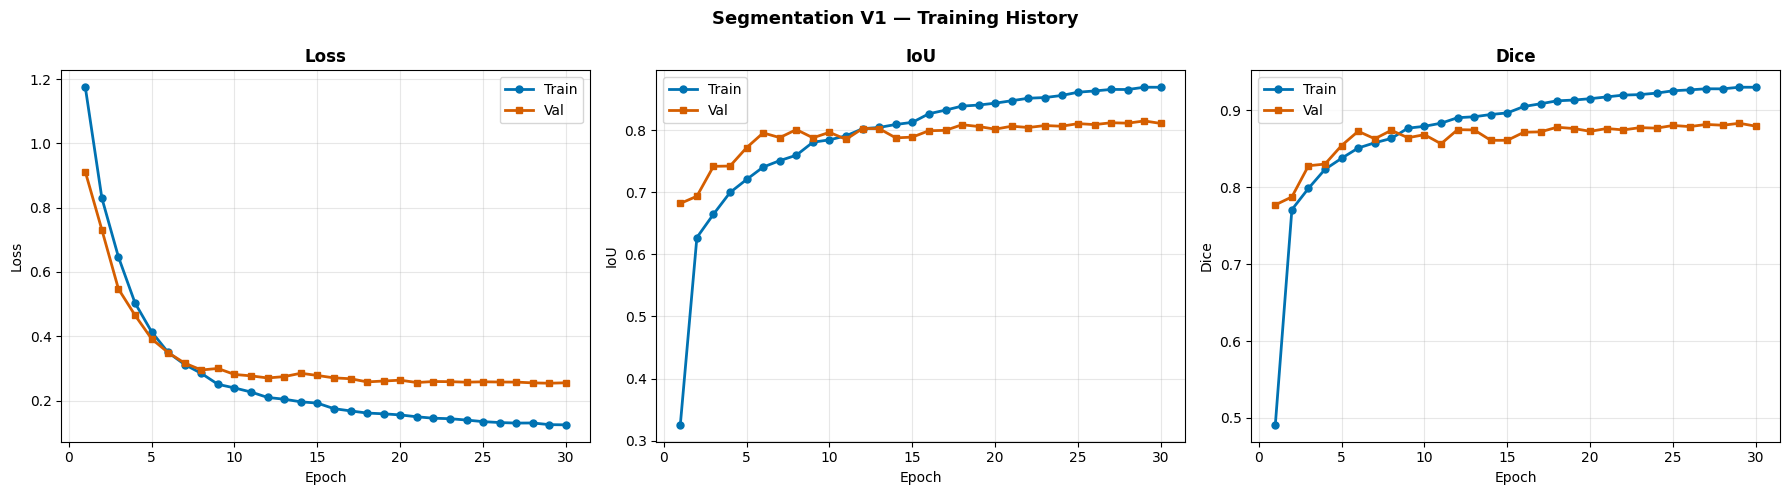

Saved → E:\Master\thesis-clean\notebooks\visualizations\segmentation_v1/training_curves.png


In [14]:
epoch_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Segmentation V1 — Training History", fontsize=13, fontweight="bold")

axes[0].plot(epoch_range, history['train_loss'], "o-", color="#0072B2", linewidth=2, markersize=5, label="Train")
axes[0].plot(epoch_range, history['val_loss'],   "s-", color="#D55E00", linewidth=2, markersize=5, label="Val")
axes[0].set_title("Loss", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epoch_range, history['train_iou'], "o-", color="#0072B2", linewidth=2, markersize=5, label="Train")
axes[1].plot(epoch_range, history['val_iou'],   "s-", color="#D55E00", linewidth=2, markersize=5, label="Val")
axes[1].set_title("IoU", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("IoU")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epoch_range, history['train_dice'], "o-", color="#0072B2", linewidth=2, markersize=5, label="Train")
axes[2].plot(epoch_range, history['val_dice'],   "s-", color="#D55E00", linewidth=2, markersize=5, label="Val")
axes[2].set_title("Dice", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Dice")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(VIZ_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {VIZ_DIR}/training_curves.png")

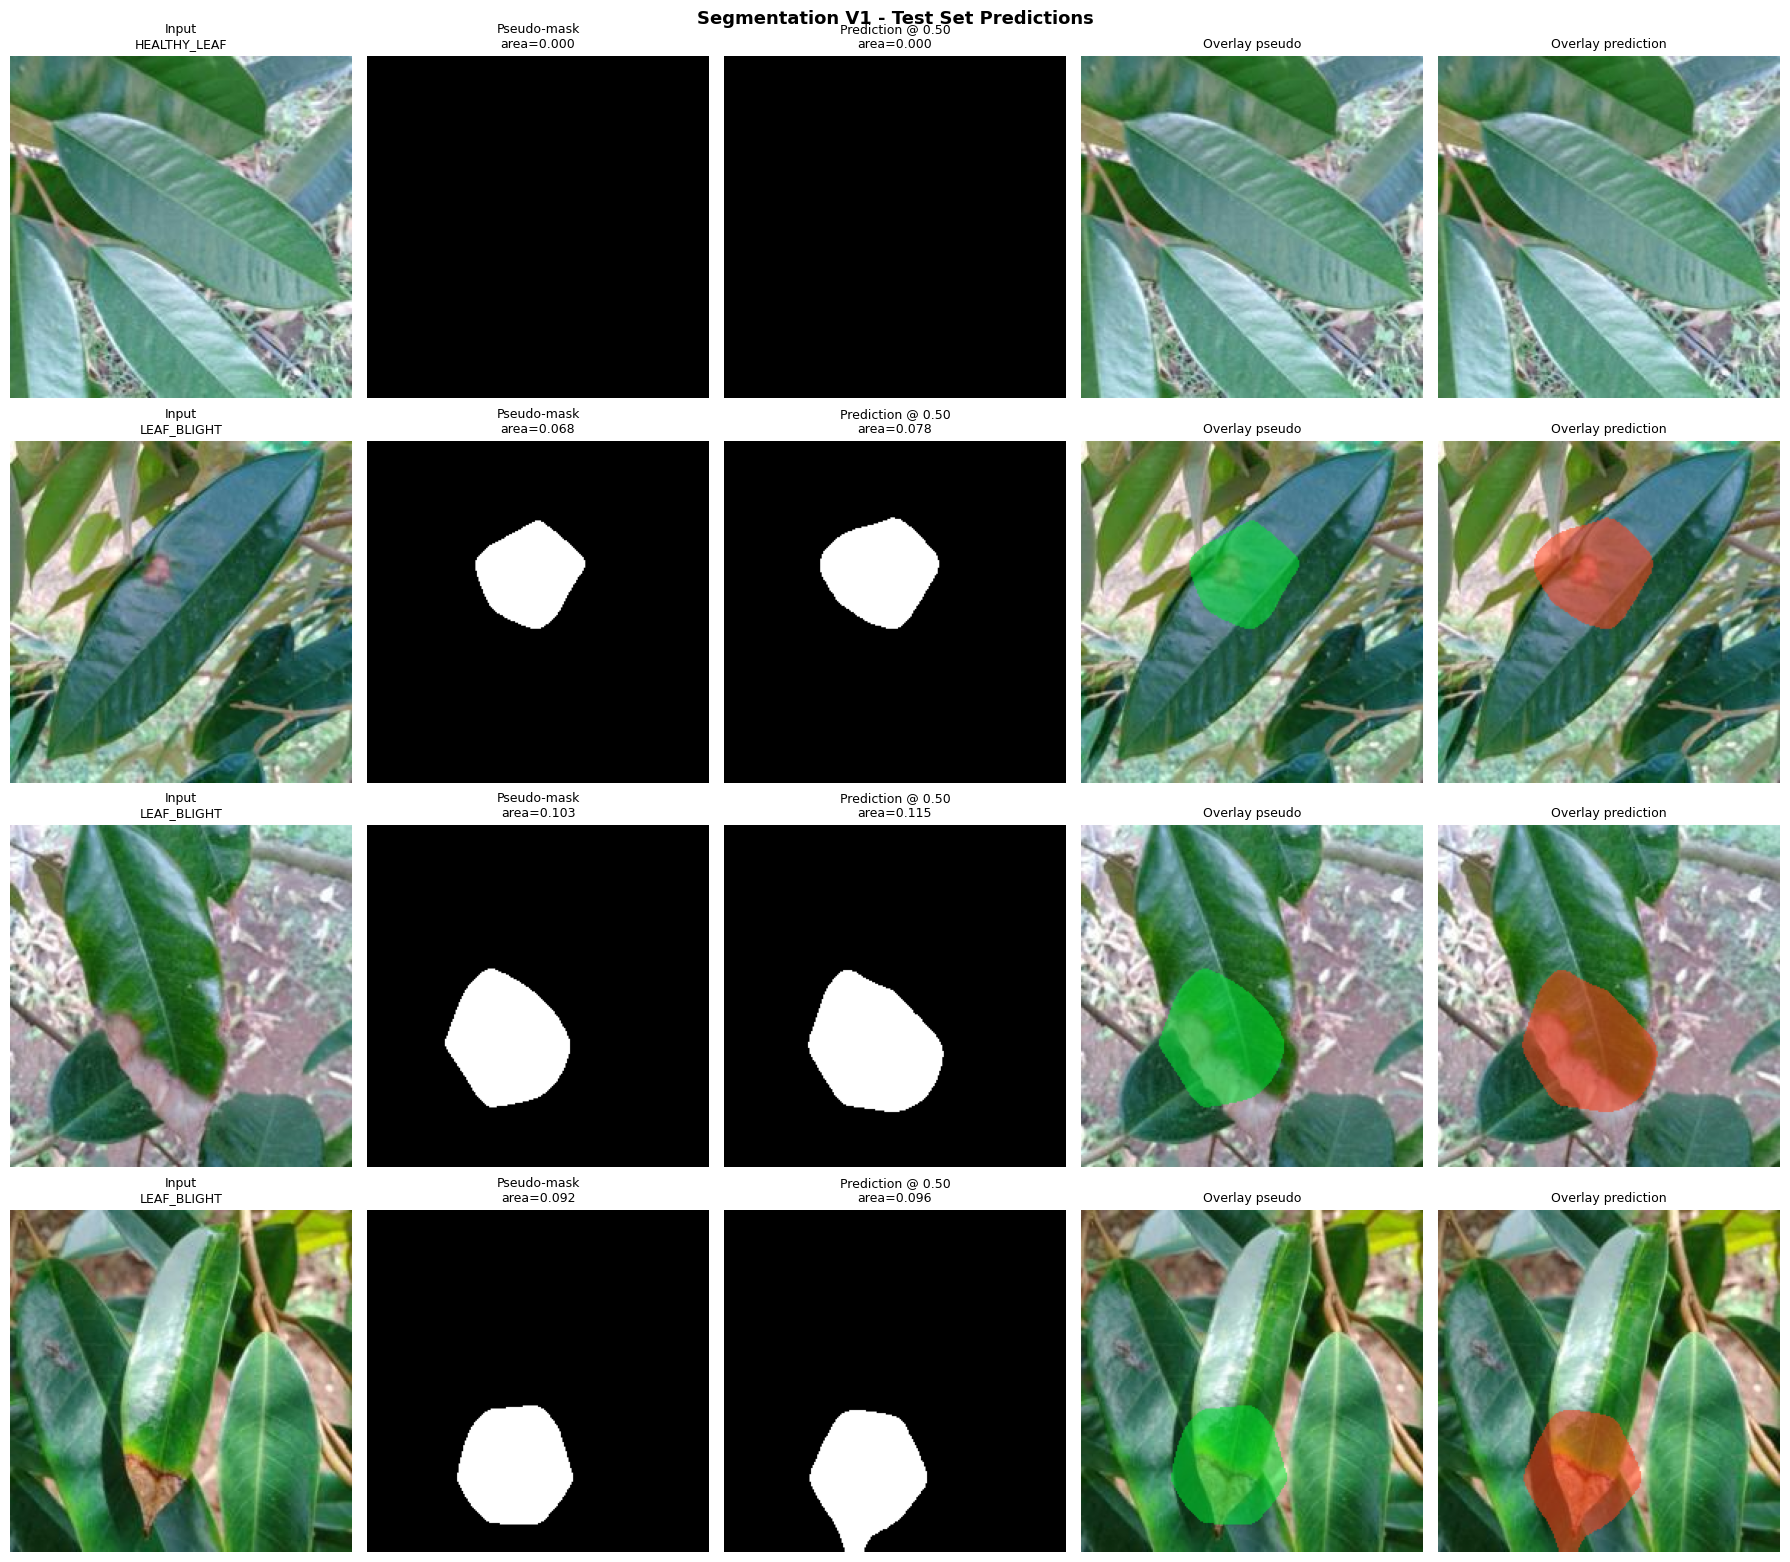

Saved -> E:\Master\thesis-clean\notebooks\visualizations\segmentation_v1\test_predictions_overlay.png


In [15]:
model.eval()
sample_batch = next(iter(test_loader))
imgs = sample_batch['image'].to(device)
masks_gt = sample_batch['label']

with torch.no_grad():
    outputs = model(imgs)
    probs = torch.sigmoid(outputs)
    preds = (probs > CONFIG["prediction_threshold"]).float()

n_show = min(4, len(imgs))
fig, axes = plt.subplots(n_show, 5, figsize=(18, 4 * n_show))
fig.suptitle("Segmentation V1 - Test Set Predictions", fontsize=13, fontweight="bold")
if n_show == 1:
    axes = axes.reshape(1, -1)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i in range(n_show):
    img_denorm = (imgs[i].cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    pseudo_mask = masks_gt[i, 0].numpy()
    pred_mask = preds[i, 0].cpu().numpy()
    prob_map = probs[i, 0].cpu().numpy()

    pseudo_overlay = img_denorm.copy()
    pseudo_overlay[pseudo_mask > 0.5] = pseudo_overlay[pseudo_mask > 0.5] * 0.45 + np.array([0.0, 0.9, 0.2]) * 0.55
    pred_overlay = img_denorm.copy()
    pred_overlay[pred_mask > 0.5] = pred_overlay[pred_mask > 0.5] * 0.45 + np.array([1.0, 0.25, 0.1]) * 0.55

    axes[i, 0].imshow(img_denorm)
    axes[i, 0].set_title(f"Input\n{sample_batch['class_name'][i]}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(pseudo_mask, cmap="gray")
    axes[i, 1].set_title(f"Pseudo-mask\narea={pseudo_mask.mean():.3f}", fontsize=9)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred_mask, cmap="gray")
    axes[i, 2].set_title(f"Prediction @ {CONFIG['prediction_threshold']:.2f}\narea={pred_mask.mean():.3f}", fontsize=9)
    axes[i, 2].axis("off")

    axes[i, 3].imshow(pseudo_overlay)
    axes[i, 3].set_title("Overlay pseudo", fontsize=9)
    axes[i, 3].axis("off")

    axes[i, 4].imshow(pred_overlay)
    axes[i, 4].set_title("Overlay prediction", fontsize=9)
    axes[i, 4].axis("off")

plt.tight_layout()
plt.savefig(VIZ_DIR / "test_predictions_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {VIZ_DIR / 'test_predictions_overlay.png'}")

---

## Kết luận — Segmentation V1 (EfficientNet-UNet)

1. **Notebook segmentation hiện đang mạnh/yếu ở đâu:** Mạnh ở pipeline end-to-end rõ và đã chạy xong: ảnh 224 x 224 từ `processed_train`, pseudo-mask V1 từ notebook 04, EfficientNet-B0 UNet pretrained, binary output 1 channel, BCEWithLogits + Dice, IoU/Dice/Precision/Recall/F1, checkpoint theo val IoU. Yếu ở chất lượng supervision: mask Grad-CAM vẫn là blob attention thô, không phải boundary lesion thật.
2. **Mask Grad-CAM có đủ tin cậy để train segmentation không:** Đủ để train baseline weakly-supervised, chưa đủ tin cậy làm ground truth cuối. Manual GT mới cho overall IoU 0.2169/Dice 0.3565, thấp hơn rất nhiều pseudo-test IoU 0.8126/Dice 0.8813.
3. **Pipeline image-mask, augmentation, loss và metric đã đúng chưa:** Sau sửa đổi, pairing đúng, size mismatch = 0, mask binary = 0 lỗi, mask resize bằng nearest-neighbor, train/val/test exact filename overlap = 0, augmentation chỉ bật cho train. Loss và metric phù hợp binary segmentation; không dựa vào pixel accuracy nền.
4. **Kết quả training cho thấy overfitting/underfitting hay học tốt:** Model học pseudo-label tốt, không underfit. Best epoch là 29 với val IoU 0.8150/val Dice 0.8832; epoch 30 giảm nhẹ. Gap train-val cuối run khoảng 0.058 IoU, cho thấy overfitting nhẹ vào pseudo-label/noise nhưng không nghiêm trọng ở pseudo-validation.
5. **Prediction mask có chất lượng như thế nào:** Trên pseudo-test, prediction bám pseudo-mask tốt, precision 0.8851 và recall 0.9091. Trên GT thật, precision chỉ 0.2460 trong khi recall 0.6472, nghĩa là model có xu hướng over-segment và tạo mask rộng hơn lesion thật.
6. **Những phần đã tối ưu hoặc bổ sung:** Gom config/seed/path, split dataset riêng để tránh augment val/test, Healthy empty-mask policy, quality gate metadata, audit pairing/alignment/binary/area/components/leakage, histogram area, overlay prediction, checkpoint consistency audit và manual GT evaluation.
7. **Các bước tiếp theo nên làm trước khi dùng mô hình:** Không dùng V1 làm final model. Trước khi dùng thực tế cần chọn checkpoint bằng GT subset, refine pseudo-label, tăng số GT thủ công, đánh giá per-class trên GT, kiểm tra threshold prediction theo precision-recall, và nếu có metadata thì split theo subject/source.